# QuantNado — Multi-Modal Dataset Exploration

This notebook walks through a complete analysis workflow using **QuantNado**: a toolkit for
efficient Zarr-backed storage and analysis of multi-modal genomic signal.

**Workflow covered:**
1. Create a unified multi-modal dataset (coverage + methylation + variants)
2. Load and inspect the dataset
3. Reduce signal over genomic regions (BED file)
4. Sample-sample correlation heatmap
5. PCA for quality control and exploratory analysis
6. Generate a feature count matrix for DESeq2
7. Extract raw per-position signal over specific regions
8. Methylation data (CpG-level from MethylDackel bedGraph)
9. Variant calls (SNP/indel from VCF)

---

## 1. Setup

> **Dependencies**  
> Install the optional example dependencies before running this notebook:
> ```bash
> pip install "quantnado[example]"
> ```
> This adds `ipykernel` and `matplotlib` on top of the core install.

In [1]:
import tarfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pyranges1 as pr

from quantnado import QuantNado
from quantnado.dataset import MultiomicsStore
from quantnado.dataset.pca import plot_pca_scatter, plot_pca_scree

## Data

The test dataset (BAM files, chr21 only) needs to be downloaded before running this notebook.
Run the cell below to fetch and extract it automatically, or manually:

```bash
# From the example/ directory
curl -L https://userweb.molbiol.ox.ac.uk/public/project/milne_group/cchahrou/quantnado/seqnado_output.tar.gz \
  | tar -xz -C multiomics_run/

```

The reference files (`reference/chr21.gtf`, `reference/promoters_1024bp.bed`) are already included in the repository.

---

In [2]:
DATA_URL = "https://userweb.molbiol.ox.ac.uk/public/project/milne_group/cchahrou/quantnado/seqnado_output.tar.gz"
REF_URL = "https://userweb.molbiol.ox.ac.uk/public/project/milne_group/cchahrou/quantnado/reference.tar.gz"
RUN_DIR = Path("multiomics_run")
RUN_DIR.mkdir(parents=True, exist_ok=True)

if not (RUN_DIR / "seqnado_output").exists():
    print("Downloading test data...")
    archive = RUN_DIR / "seqnado_output.tar.gz"
    urllib.request.urlretrieve(DATA_URL, archive)
    print("Extracting...")
    with tarfile.open(archive) as tf:
        tf.extractall(RUN_DIR)
    archive.unlink()
    print("Done.")
else:
    print("Test data already present — skipping download.")

if not (RUN_DIR / "reference").exists():
    print("Downloading reference data...")
    urllib.request.urlretrieve(REF_URL, RUN_DIR / "reference.tar.gz")
    with tarfile.open(RUN_DIR / "reference.tar.gz") as tf:
        tf.extractall(RUN_DIR)
    (RUN_DIR / "reference.tar.gz").unlink()
    print("Done.")
else:
    print("Reference data already present — skipping download.")

Extracting...


/tmp/ipykernel_2454684/3704453981.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(RUN_DIR)


Done.
Done.


/tmp/ipykernel_2454684/3704453981.py:22: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(RUN_DIR)


In [3]:
# Paths relative to this notebook (example/)
OUT_DIR = RUN_DIR / "seqnado_output"
REF_DIR = RUN_DIR / "reference"

MS_PATH = RUN_DIR / "dataset"  # MultiomicsStore directory
BED_FILE = REF_DIR / "promoters_1024bp.bed"
GTF_FILE = REF_DIR / "chr21.gtf"
FIG_DIR = RUN_DIR / "figures"

FIG_DIR.mkdir(parents=True, exist_ok=True)

---
## 2. Create a Unified Multi-Modal Dataset

`MultiomicsStore.from_files()` creates one directory (`dataset/`) containing a
sub-Zarr for each supplied modality:

| Sub-store | Input | What is stored |
|---|---|---|
| `coverage.zarr` | BAM files | per-base read depth (dense, sample × position) |
| `methylation.zarr` | MethylDackel bedGraph | CpG methylation % and counts (sparse) |
| `variants.zarr` | VCF.gz files | genotype, allele depths, quality (sparse) |

Run this cell once; it is skipped automatically if the store already exists.

In [4]:
if not MS_PATH.exists():
    bam_files = sorted(OUT_DIR.rglob("*.bam"))
    bedgraph_files = sorted((OUT_DIR / "meth/methylation/methyldackel").glob("*.bedGraph"))
    vcf_files = sorted((OUT_DIR / "snp/variant").glob("*.vcf.gz"))

    # MethylDackel embeds genome/suffix in the filename; strip it to match BAM stems
    meth_sample_names = [f.name.split("_hg38")[0] for f in bedgraph_files]

    print(f"BAM files       : {len(bam_files)}")
    print(f"bedGraph files  : {[f.name for f in bedgraph_files]}")
    print(f"VCF files       : {[f.name for f in vcf_files]}")

    ms = MultiomicsStore.from_files(
        store_dir=MS_PATH,
        bam_files=bam_files,
        bedgraph_files=bedgraph_files,
        vcf_files=vcf_files,
        bedgraph_sample_names=meth_sample_names,
        test=True,  # restrict to chr21/chr22/chrY for this test dataset
        overwrite=True,
    )
    print("\nDone.")
else:
    print(f"Dataset already exists at {MS_PATH} — skipping creation.")

2026-03-06 17:21:57.283 | INFO     | quantnado.dataset.multiomics:from_files:143 - Building coverage store from 10 BAM file(s)...
2026-03-06 17:21:57.284 | INFO     | quantnado.dataset.bam:from_bam_files:477 - Extracting chromsizes from multiomics_run/seqnado_output/atac/aligned/atac.bam
2026-03-06 17:21:57.357 | INFO     | quantnado.dataset.bam:_init_store:276 - Initialized Zarr store at multiomics_run/dataset/coverage.zarr
2026-03-06 17:21:57.362 | INFO     | quantnado.dataset.bam:_process_single_sample:386 - Processing sample 1/10: atac


BAM files       : 10
bedGraph files  : ['meth-rep1_hg38_CpG_inverted.bedGraph', 'meth-rep2_hg38_CpG_inverted.bedGraph']
VCF files       : ['snp.vcf.gz']


2026-03-06 17:21:58.418 | INFO     | quantnado.dataset.bam:_process_single_sample:386 - Processing sample 2/10: chip-rx_MLL
2026-03-06 17:21:59.920 | INFO     | quantnado.dataset.bam:_process_single_sample:386 - Processing sample 3/10: chip-rx_input
2026-03-06 17:22:01.174 | INFO     | quantnado.dataset.bam:_process_single_sample:386 - Processing sample 4/10: meth-rep1
2026-03-06 17:22:03.314 | INFO     | quantnado.dataset.bam:_process_single_sample:386 - Processing sample 5/10: meth-rep2
2026-03-06 17:22:04.781 | INFO     | quantnado.dataset.bam:_process_single_sample:386 - Processing sample 6/10: rna-spikein-control-rep1
2026-03-06 17:22:06.042 | INFO     | quantnado.dataset.bam:_process_single_sample:386 - Processing sample 7/10: rna-spikein-control-rep2
2026-03-06 17:22:07.368 | INFO     | quantnado.dataset.bam:_process_single_sample:386 - Processing sample 8/10: rna-spikein-treated-rep1
2026-03-06 17:22:08.734 | INFO     | quantnado.dataset.bam:_process_single_sample:386 - Process


Done.


---
## 3. Load and Inspect the Dataset

In [5]:
# Open the unified store
ms = MultiomicsStore.open(MS_PATH)
print(ms)

# QuantNado wraps the coverage sub-store and provides reduce / PCA / feature-count methods
qn = QuantNado(ms.coverage)

2026-03-06 17:22:11.595 | INFO     | quantnado.dataset.bam:_load_existing:282 - Resuming existing store at multiomics_run/dataset/coverage.zarr
2026-03-06 17:22:11.601 | INFO     | quantnado.dataset.methylation:_load_existing:178 - Resuming existing MethylStore at multiomics_run/dataset/methylation.zarr
2026-03-06 17:22:11.606 | INFO     | quantnado.dataset.variants:_load_existing:228 - Resuming existing VariantStore at multiomics_run/dataset/variants.zarr


MultiomicsStore at 'multiomics_run/dataset'
  modalities : ['coverage', 'methylation', 'variants']
  coverage    : 10 samples, 1 chrom(s)
  methylation : 2 samples, 1 chrom(s)
  variants    : 1 samples, 1 chrom(s)


In [6]:
print("Available modalities:", ms.modalities)
print("Chromosomes        :", ms.chromosomes)
print()
for modality, names in ms.samples.items():
    print(f"{modality:<12}: {names}")

Available modalities: ['coverage', 'methylation', 'variants']
Chromosomes        : ['chr21']

coverage    : ['atac', 'chip-rx_MLL', 'chip-rx_input', 'meth-rep1', 'meth-rep2', 'rna-spikein-control-rep1', 'rna-spikein-control-rep2', 'rna-spikein-treated-rep1', 'rna-spikein-treated-rep2', 'snp']
methylation : ['meth-rep1', 'meth-rep2']
variants    : ['snp']


In [7]:
# Unified metadata — one row per sample, with a 'modalities' column
metadata = ms.get_metadata()
metadata

,sample_hash,completed,sparsity,modalities
sample_id,,,,
atac,96ae824c5c35c004df1b9db3db07283e,True,99.904594,coverage
chip-rx_MLL,ea6b78070b8d28b7a0239eca45893bd4,True,95.253860,coverage
chip-rx_input,0b963a3f5fbb579eadc24b2c2b4e0a2b,True,99.923912,coverage
meth-rep1,f5ba0583afa25559ed30c9e8e2709f07,True,94.216675,"coverage, methylation"
meth-rep2,bcc7e3bf38ae81f6947662683190e221,True,93.745697,"coverage, methylation"
rna-spikein-control-rep1,2414b9280438e98f0c7cf50d5324bc2f,True,97.987144,coverage
rna-spikein-control-rep2,9b73f71b7438cdc6081be20663ee4929,True,98.167877,coverage
rna-spikein-treated-rep1,53da554c5e301439abe48b13b8838b67,True,96.408737,coverage
rna-spikein-treated-rep2,NaN,True,96.751144,coverage


---
## 4. Reduce Signal over Genomic Regions

Aggregate per-base signal across genomic intervals (e.g. promoters, peaks) to produce a
compact `(regions × samples)` matrix. Useful for downstream analysis such as PCA and clustering.

Reduction methods: `mean`, `sum`, `max`, `min`, `median`.

In [8]:
# Reduce mean signal over each promoter window
promoter_signal = qn.reduce(intervals_path=str(BED_FILE), reduction="mean")
promoter_signal

2026-03-06 17:22:11.735 | INFO     | quantnado.dataset.reduce:_log_chromosome_overlap:60 - Chromosome compatibility check: 1 shared chromosomes out of 1 in BED/GTF file and 1 in dataset
2026-03-06 17:22:11.735 | DEBUG    | quantnado.dataset.reduce:_log_chromosome_overlap:66 - Shared chromosomes: ['chr21']


<xarray.Dataset> Size: 385kB
Dimensions:       (ranges: 1456, sample: 10)
Coordinates:
  * ranges        (ranges) int64 12kB 0 1 2 3 4 5 ... 1451 1452 1453 1454 1455
    range_index   (ranges) int64 12kB 0 1 2 3 4 5 ... 1451 1452 1453 1454 1455
    start         (ranges) int64 12kB 5011852 5011852 ... 46635162 46635162
    end           (ranges) int64 12kB 5012876 5012876 ... 46636186 46636186
    range_length  (ranges) int64 12kB 1024 1024 1024 1024 ... 1024 1024 1024
    contig        (ranges) object 12kB 'chr21' 'chr21' ... 'chr21' 'chr21'
    strand        (ranges) object 12kB '+' '+' '+' '+' '+' ... '+' '+' '+' '+'
    name          (ranges) object 12kB 'LOC124905051:XM_047441065.1' ... 'PRM...
  * sample        (sample) <U24 960B 'atac' 'chip-rx_MLL' ... 'snp'
Data variables:
    sum           (ranges, sample) float32 58kB dask.array<chunksize=(1456, 1), meta=np.ndarray>
    count         (ranges, sample) int64 116kB dask.array<chunksize=(1456, 1), meta=np.ndarray>
    mean          (ranges, sample) float64 116kB dask.array<chunksize=(1456, 1), meta=np.ndarray>

In [9]:
# Alternatively: derive promoter windows directly from a GTF annotation
# promoter_signal = qn.reduce(feature_type="promoter", gtf_path=str(GTF_FILE), reduction="mean")

In [10]:
# Signal matrix: (regions × samples)
signal_matrix = promoter_signal["mean"].values
print(f"Signal matrix shape: {signal_matrix.shape}  (regions × samples)")

Signal matrix shape: (1456, 10)  (regions × samples)


### 4a. Clustered Heatmap of Promoter Signal

/ceph/project/milne_group/cchahrou/software/miniforge3/envs/quantnado_dev/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/ceph/project/milne_group/cchahrou/software/miniforge3/envs/quantnado_dev/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


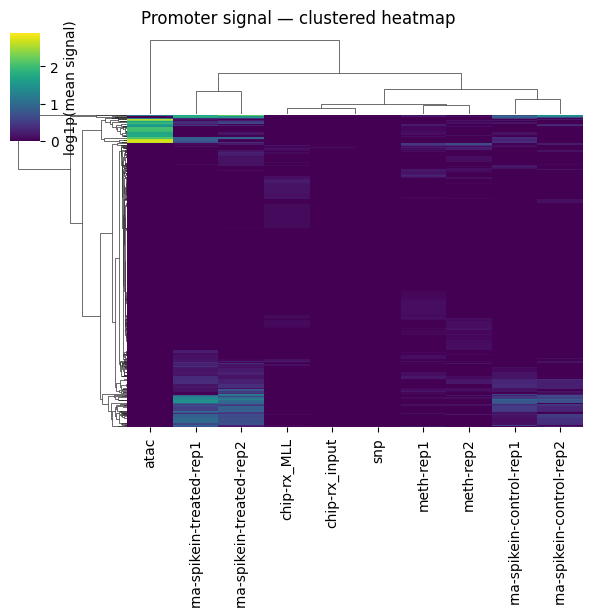

In [11]:
# Log-transform to compress dynamic range, then cluster
log_signal = np.log1p(signal_matrix)

g = sns.clustermap(
    log_signal,
    cmap="viridis",
    yticklabels=False,
    xticklabels=qn.samples,
    figsize=(6, 6),
    col_cluster=True,
    row_cluster=True,
    cbar_kws={"label": "log1p(mean signal)"},
)
g.figure.suptitle("Promoter signal — clustered heatmap", y=1.02)
g.savefig(FIG_DIR / "promoter_clustermap.png", bbox_inches="tight")
plt.show()

### 4b. Sample–Sample Correlation

/ceph/project/milne_group/cchahrou/software/miniforge3/envs/quantnado_dev/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/ceph/project/milne_group/cchahrou/software/miniforge3/envs/quantnado_dev/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


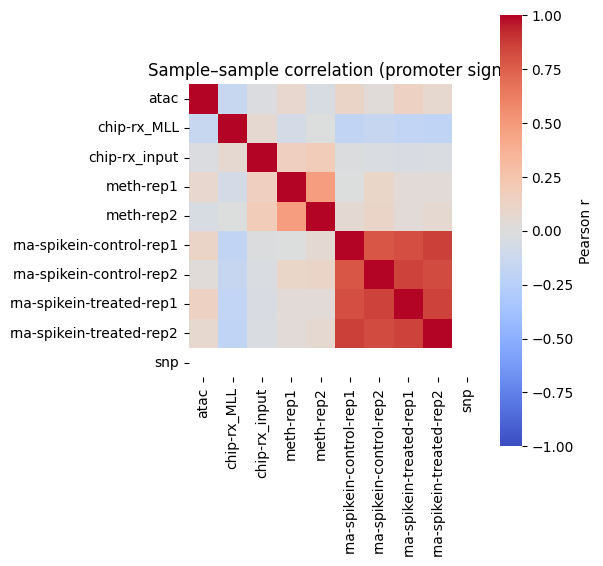

In [12]:
# Pearson correlation across all promoter regions
corr = np.corrcoef(log_signal.T)  # samples × samples

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(
    corr,
    xticklabels=qn.samples,
    yticklabels=qn.samples,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
    cbar_kws={"label": "Pearson r"},
)
ax.set_title("Sample–sample correlation (promoter signal)")
fig.tight_layout()
fig.savefig(FIG_DIR / "sample_correlation.png")
plt.show()

---
## 5. PCA

Principal component analysis on the promoter signal matrix is a standard QC step: it reveals
whether samples cluster by expected biological groupings (e.g. cell type, treatment) and flags
outliers.

In [13]:
pca_obj, pca_result = qn.pca(
    promoter_signal["mean"],
    n_components=8,
    nan_handling_strategy="drop",  # remove regions with missing values
)

explained = np.asarray(pca_obj.explained_variance_ratio_)
print("Explained variance per PC:")
for i, ev in enumerate(explained, 1):
    print(f"  PC{i}: {ev:.1%}")

Explained variance per PC:
  PC1: 76.5%
  PC2: 21.4%
  PC3: 1.2%
  PC4: 0.4%
  PC5: 0.3%
  PC6: 0.1%
  PC7: 0.1%
  PC8: 0.0%


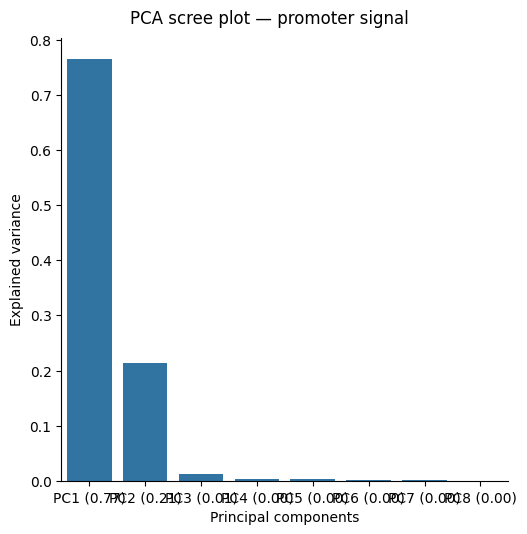

In [14]:
# Scree plot
scree = plot_pca_scree(pca_obj)
scree.figure.suptitle("PCA scree plot — promoter signal", y=1.02)
scree.savefig(FIG_DIR / "pca_scree.png", bbox_inches="tight")
plt.show()

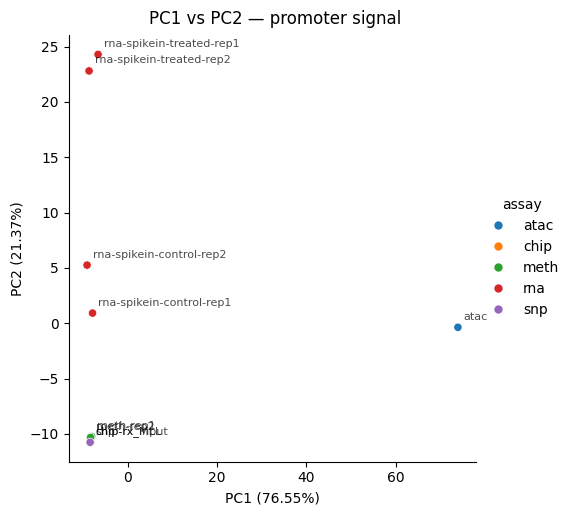

In [15]:
# PC1 vs PC2 scatter — colour by a metadata column of your choice
metadata["assay"] = metadata.index.str.split("-").str[0]
COLOUR_BY = "assay"  # change to any column in metadata
SHAPE_BY = "condition"  # or set to None

scatter = plot_pca_scatter(
    pca_obj,
    pca_result,
    xaxis_pc=1,
    yaxis_pc=2,
    metadata_df=metadata,
    colour_by=COLOUR_BY,
    shape_by=SHAPE_BY,
    height=5,
)
scatter.figure.suptitle("PC1 vs PC2 — promoter signal", y=1.02)
scatter.savefig(FIG_DIR / "pca_scatter_pc1_pc2.png", bbox_inches="tight")
plt.show()

---
## 6. Feature Count Matrix (DESeq2-compatible)

Sum signal across gene bodies to produce an integer count matrix ready for differential
expression analysis in DESeq2 or edgeR.

In [16]:
counts, features = qn.feature_counts(
    bed_file=str(BED_FILE),
    feature_type="gene",
    integerize=True,
)

print(f"Count matrix: {counts.shape[0]} genes × {counts.shape[1]} samples")
counts.head()

2026-03-06 17:24:19.888 | INFO     | quantnado.dataset.reduce:_log_chromosome_overlap:60 - Chromosome compatibility check: 1 shared chromosomes out of 1 in BED/GTF file and 1 in dataset
2026-03-06 17:24:19.889 | DEBUG    | quantnado.dataset.reduce:_log_chromosome_overlap:66 - Shared chromosomes: ['chr21']


Count matrix: 1456 genes × 10 samples


,atac,chip-rx_MLL,chip-rx_input,meth-rep1,meth-rep2,rna-spikein-control-rep1,rna-spikein-control-rep2,rna-spikein-treated-rep1,rna-spikein-treated-rep2,snp
ranges,,,,,,,,,,
0,0,144,0,0,0,0,0,0,0,0
1,0,144,0,0,0,0,0,0,0,0
2,0,0,0,0,0,385,276,161,448,0
3,0,0,0,0,0,385,276,161,448,0
4,0,0,0,0,0,385,276,161,448,0


In [17]:
counts_path = OUT_DIR / "counts_matrix.csv"
counts.to_csv(counts_path)
print(f"Counts saved to {counts_path}")

Counts saved to multiomics_run/seqnado_output/counts_matrix.csv


---
## 7. Extract Raw Signal over Regions

`qn.extract()` returns the full per-position signal for each genomic interval as a
`(intervals × positions × samples)` DataArray — useful for metagene plots, coverage
tracks, and deep-learning feature engineering.

Setting `fixed_width` centres all intervals to the same length; `bin_size` downsamples
positions into coarser bins.

In [18]:
# Extract 2 kb windows around promoter TSSs, binned into 50 bp resolution
binned = qn.extract(
    feature_type="promoter",
    gtf_path=str(GTF_FILE),
    fixed_width=2000,  # centre each TSS in a 2 kb window
    anchor="start",  # strand-aware: 5' end of gene
    bin_size=50,  # bin into 50 bp windows  →  40 bins per region
    bin_agg="mean",
)
print(binned)  # (intervals, bin, sample)

2026-03-06 17:24:38.031 | WARNING  | quantnado.dataset.features:extract_promoters:206 - No 'gene' features found in GTF; falling back to 'transcript'
2026-03-06 17:24:38.050 | INFO     | quantnado.dataset.reduce:_log_chromosome_overlap:60 - Chromosome compatibility check: 1 shared chromosomes out of 1 in GTF and 1 in dataset
2026-03-06 17:24:38.051 | DEBUG    | quantnado.dataset.reduce:_log_chromosome_overlap:66 - Shared chromosomes: ['chr21']


<xarray.DataArray 'getitem-29186fca07612f56d750af4ad05e45e4' (interval: 986,
                                                              bin: 40,
                                                              sample: 10)> Size: 2MB
dask.array<getitem, shape=(986, 40, 10), dtype=float32, chunksize=(33, 40, 1), chunktype=numpy.ndarray>
Coordinates:
  * interval  (interval) int64 8kB 0 1 2 3 4 5 6 ... 979 980 981 982 983 984 985
    start     (interval) int64 8kB 46706966 46706810 ... 9732506 9689726
    end       (interval) int64 8kB 46708166 46708010 ... 9733706 9690926
    contig    (interval) <U5 20kB 'chr21' 'chr21' 'chr21' ... 'chr21' 'chr21'
    strand    (interval) object 8kB '+' '-' '-' '-' '-' ... '+' '+' '+' '+' '-'
  * bin       (bin) int64 320B 0 1 2 3 4 5 6 7 8 ... 31 32 33 34 35 36 37 38 39
  * sample    (sample) <U24 960B 'atac' 'chip-rx_MLL' ... 'snp'
Attributes:
    fixed_width:  2000
    anchor:       start
    bin_size:     50
    bin_agg:      mean


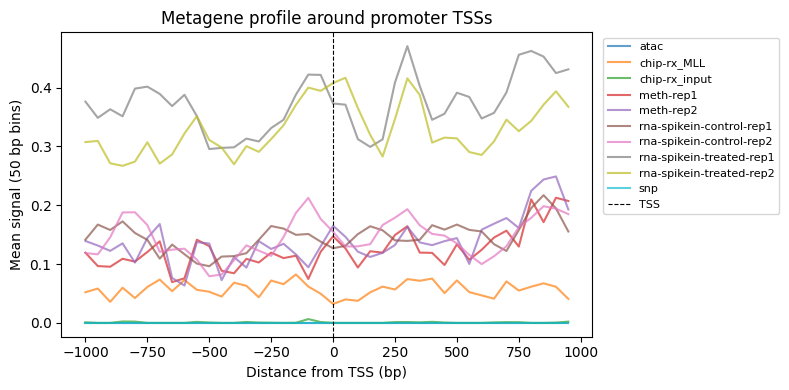

In [19]:
# Metagene plot: average signal across all promoters per sample
data = binned.compute()  # materialise the dask array
mean_profile = data.mean(dim="interval")  # (bin, sample)

bin_centers = np.arange(-1000, 1000, 50)  # relative positions in bp

fig, ax = plt.subplots(figsize=(8, 4))
for sample in mean_profile.coords["sample"].values:
    ax.plot(bin_centers, mean_profile.sel(sample=sample).values, alpha=0.7, label=sample)

ax.axvline(0, color="black", linestyle="--", linewidth=0.8, label="TSS")
ax.set_xlabel("Distance from TSS (bp)")
ax.set_ylabel("Mean signal (50 bp bins)")
ax.set_title("Metagene profile around promoter TSSs")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "metagene_tss.png")
plt.show()

---
## 8. Extract Signal for a Single Genomic Region

Use `extract_region` to pull the raw per-base coverage for any genomic locus across all samples.

In [20]:
runx1_coords = "chr21:34785801-35051302"
region = qn.extract_region(runx1_coords)  # RUNX1 locus (chr21, hg38)
print(f"Region shape: {region.shape}  (samples × positions)")

2026-03-06 17:24:48.444 | INFO     | quantnado.dataset.bam:extract_region:983 - Extracted region chr21:34785801-35051302 (265501 bp) for 10 sample(s)


Region shape: (10, 265501)  (samples × positions)


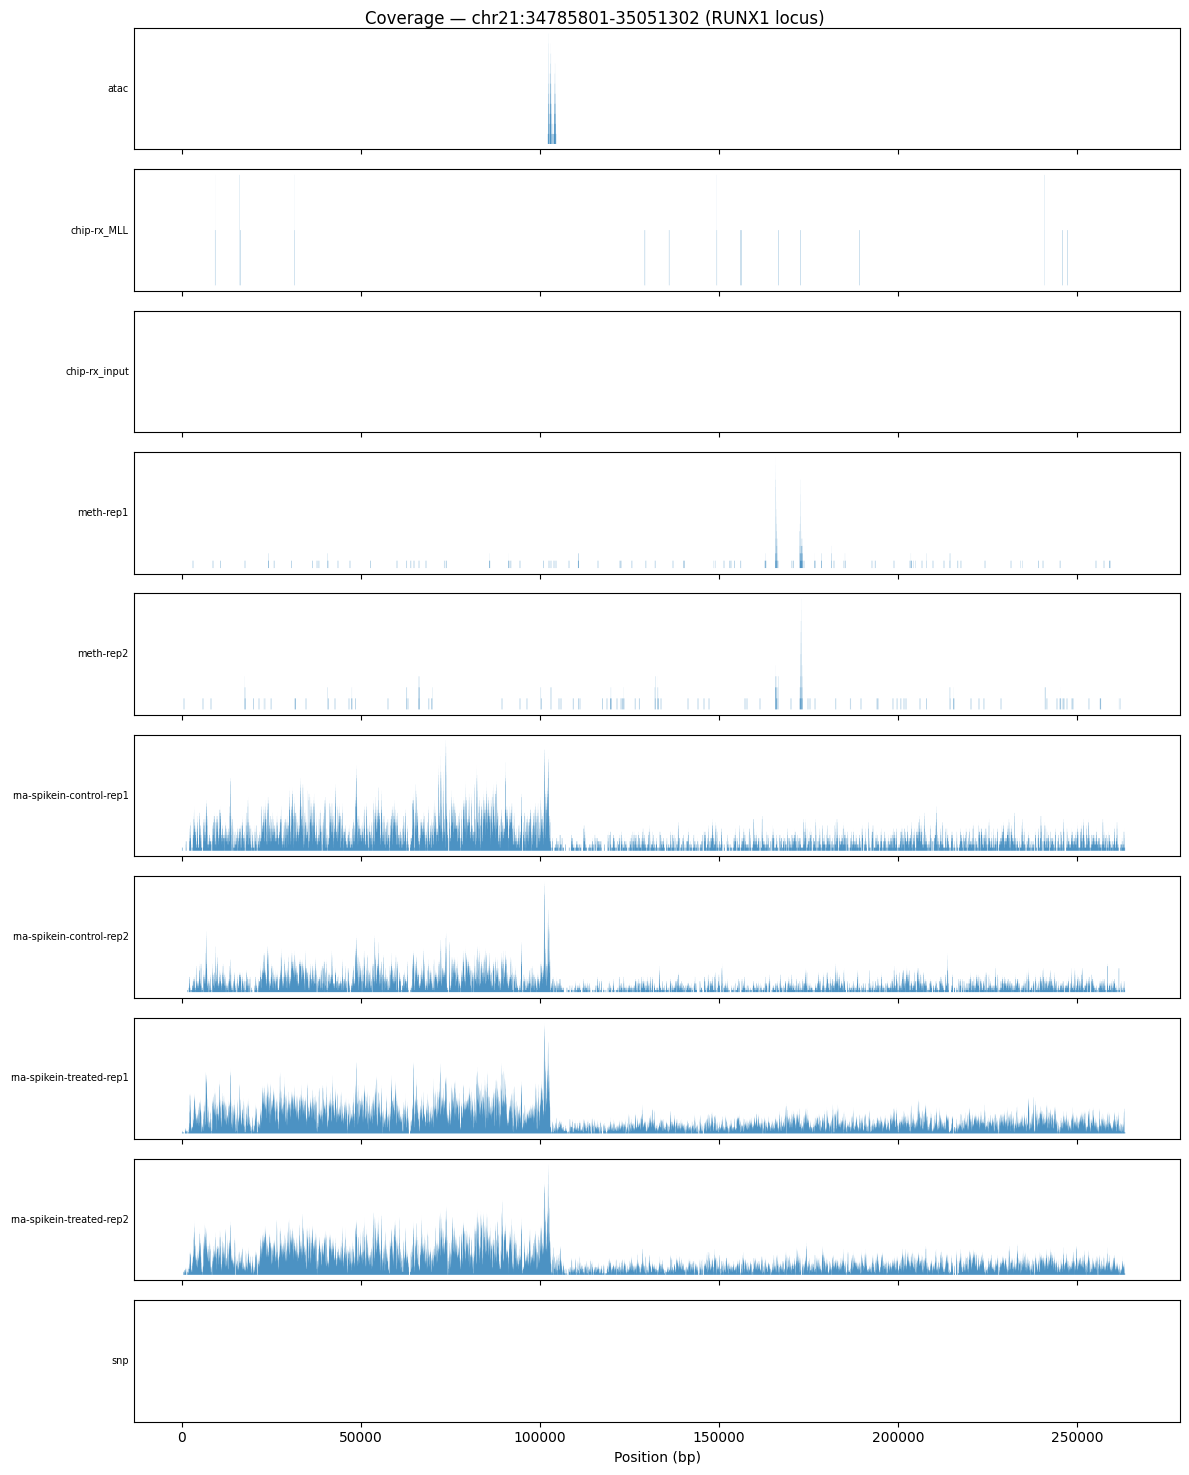

In [21]:
region_data = region.compute()  # (samples, positions)
positions = np.arange(region_data.shape[1])

fig, axes = plt.subplots(len(qn.samples), 1, figsize=(12, 1.5 * len(qn.samples)), sharex=True)

if len(qn.samples) == 1:
    axes = [axes]

for ax, sample in zip(axes, region_data.coords["sample"].values):
    ax.fill_between(positions, region_data.sel(sample=sample).values, alpha=0.8)
    ax.set_ylabel(sample, fontsize=7, rotation=0, ha="right", va="center")
    ax.set_yticks([])

axes[-1].set_xlabel("Position (bp)")
fig.suptitle(f"Coverage — {runx1_coords} (RUNX1 locus)")
fig.tight_layout()
fig.savefig(FIG_DIR / "region_RUNX1.png")
plt.show()

---
## 8. Methylation (CpG-level from MethylDackel)

`ms.methylation` is a `MethylStore` — a sparse Zarr store where each chromosome has:
- `positions` — the union of CpG start coordinates (0-based) across all samples
- `methylation_pct` — methylation percentage per site per sample (`NaN` = not covered)
- `n_methylated` / `n_unmethylated` — read counts

In [22]:
meth = ms.methylation
print(f"Samples : {meth.sample_names}")
for chrom in meth.chromosomes:
    print(f"  {chrom}: {len(meth.get_positions(chrom)):,} CpG sites")

# Lazy DataArray — sample × CpG position
meth_xr = meth.to_xarray(variable="methylation_pct")
print()
print(meth_xr["chr21"])

Samples : ['meth-rep1', 'meth-rep2']
  chr21: 19,751 CpG sites

<xarray.DataArray 'array-b15e15809889fe3f377a3543844cf5ce' (sample: 2,
                                                            position: 19751)> Size: 158kB
dask.array<array, shape=(2, 19751), dtype=float32, chunksize=(1, 19751), chunktype=numpy.ndarray>
Coordinates:
  * sample     (sample) <U9 72B 'meth-rep1' 'meth-rep2'
    completed  (sample) bool 2B True True
  * position   (position) int64 158kB 5067013 5067171 ... 46698163 46698204
Attributes:
    variable:    methylation_pct
    chromosome:  chr21


### 8a. Methylation distribution

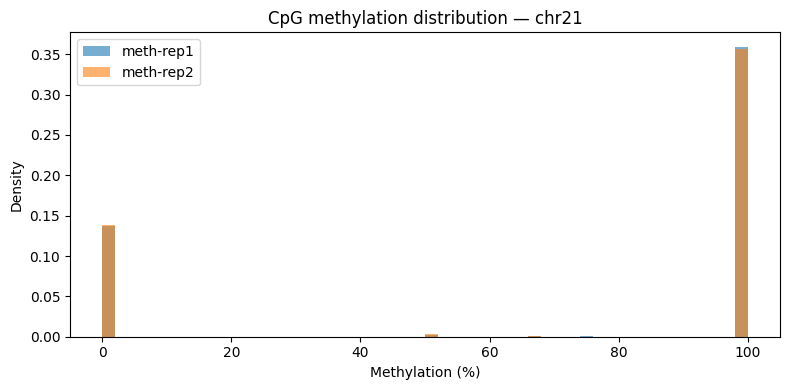

In [23]:
meth_data = meth_xr["chr21"].compute()

fig, ax = plt.subplots(figsize=(8, 4))
for sample in meth.sample_names:
    vals = meth_data.sel(sample=sample).values
    vals = vals[~np.isnan(vals)]
    ax.hist(vals, bins=50, alpha=0.6, label=sample, density=True)

ax.set_xlabel("Methylation (%)")
ax.set_ylabel("Density")
ax.set_title("CpG methylation distribution — chr21")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "methylation_distribution.png")
plt.show()

### 8b. Replicate correlation at shared CpG sites

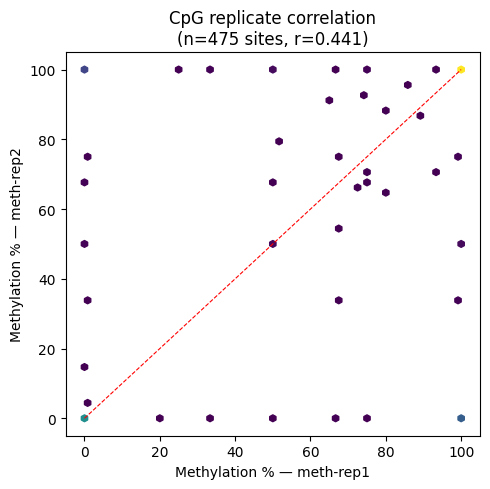

In [24]:
s1_name, s2_name = meth.sample_names[0], meth.sample_names[1]
s1 = meth_data.sel(sample=s1_name).values
s2 = meth_data.sel(sample=s2_name).values

covered = ~np.isnan(s1) & ~np.isnan(s2)
r = np.corrcoef(s1[covered], s2[covered])[0, 1]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hexbin(s1[covered], s2[covered], gridsize=60, cmap="viridis", mincnt=1)
ax.plot([0, 100], [0, 100], "r--", linewidth=0.8)
ax.set_xlabel(f"Methylation % — {s1_name}")
ax.set_ylabel(f"Methylation % — {s2_name}")
ax.set_title(f"CpG replicate correlation\n(n={covered.sum():,} sites, r={r:.3f})")
fig.tight_layout()
fig.savefig(FIG_DIR / "methylation_replicate_correlation.png")
plt.show()

### 8c. Extract methylation over a specific region

In [25]:
region_meth = meth.extract_region(runx1_coords, variable="methylation_pct")
print(f"Shape: {region_meth.shape}  (samples × CpG sites in RUNX1)")
print(f"CpG positions covered: {(~np.isnan(region_meth.values)).sum(axis=1)}")

Shape: (2, 185)  (samples × CpG sites in RUNX1)
CpG positions covered: [103  88]


### 8d. Methylation metaplot over promoters

For each 1024 bp promoter window on chr21, CpG sites are assigned to one of 32 bins
relative to the TSS (position 0). Minus-strand promoters are strand-corrected so that
the TSS is always at the centre. The profile shows mean methylation % per bin across all
promoters.

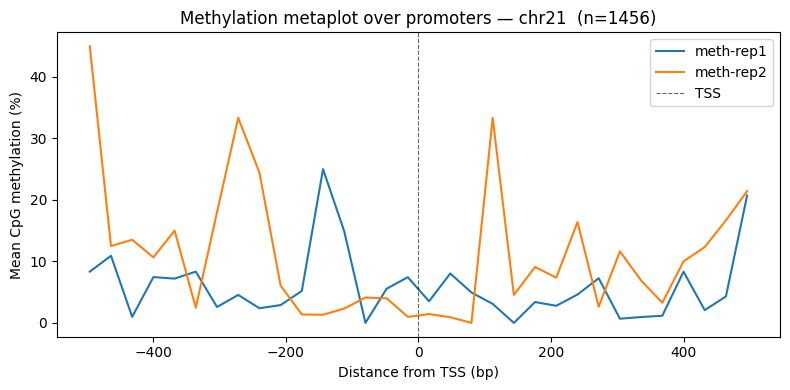

In [26]:
N_BINS = 32  # bins across the 1024 bp promoter window

# Load promoter windows restricted to chr21
bed = pr.read_bed(str(BED_FILE))

bed = bed[bed["Chromosome"] == "chr21"].reset_index(drop=True)
win_len = int(bed["End"].iloc[0] - bed["Start"].iloc[0])  # 1024

# Sparse CpG positions and methylation matrix
cpg_pos = meth.get_positions("chr21")  # shape (n_cpg,)
meth_mat = meth_xr["chr21"].compute().values  # shape (n_samples, n_cpg)
n_samp = len(meth.sample_names)

bin_sum = np.zeros((n_samp, N_BINS))
bin_cnt = np.zeros((n_samp, N_BINS))

for _, row in bed.iterrows():
    start, end, strand = int(row["Start"]), int(row["End"]), row["Strand"]
    idx = np.where((cpg_pos >= start) & (cpg_pos < end))[0]
    if idx.size == 0:
        continue
    rel = cpg_pos[idx] - start  # 0-based within window
    if strand == "-":
        rel = (win_len - 1) - rel  # flip: TSS → position 0
    bins = (rel * N_BINS // win_len).clip(0, N_BINS - 1)
    for s in range(n_samp):
        vals = meth_mat[s, idx]
        for b, v in zip(bins, vals):
            if not np.isnan(v):
                bin_sum[s, b] += v
                bin_cnt[s, b] += 1

with np.errstate(invalid="ignore"):
    profile = np.where(bin_cnt > 0, bin_sum / bin_cnt, np.nan)

# x-axis: bp relative to TSS (window centred at 0)
half = win_len / 2
bin_centers = np.linspace(-half, half, N_BINS, endpoint=False) + win_len / (2 * N_BINS)

fig, ax = plt.subplots(figsize=(8, 4))
for i, sample in enumerate(meth.sample_names):
    sns.lineplot(x=bin_centers, y=profile[i], label=sample, ax=ax)

ax.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.6, label="TSS")
ax.set_xlabel("Distance from TSS (bp)")
ax.set_ylabel("Mean CpG methylation (%)")
ax.set_title(f"Methylation metaplot over promoters — chr21  (n={len(bed)})")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "methylation_metaplot_promoters.png")
plt.show()

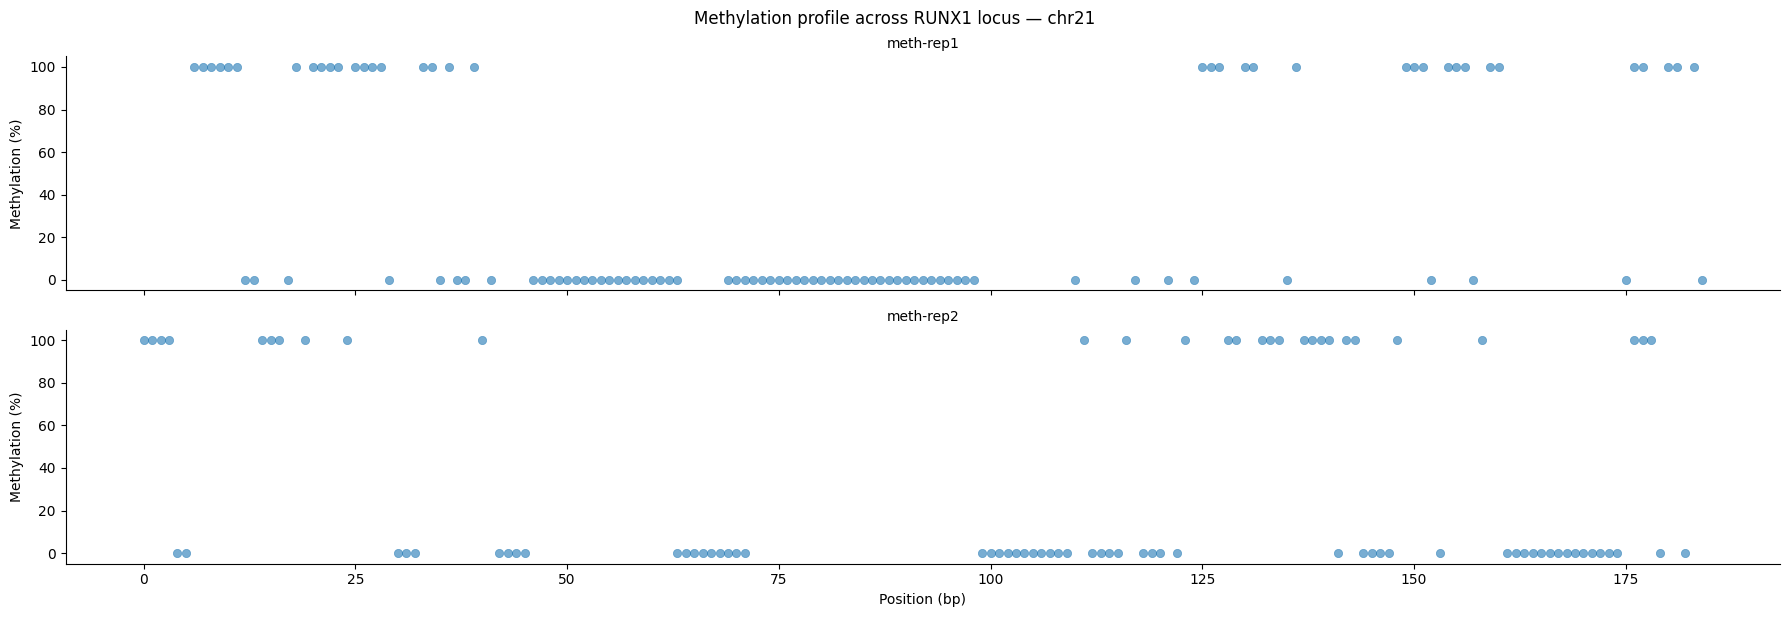

In [27]:
# plot methylation levels at runx1_coords

region_meth_data = region_meth.compute()  # (samples, positions)
positions = np.arange(region_meth_data.shape[1])

# facet by replicate
g = sns.FacetGrid(
    pd.DataFrame(region_meth_data.values, columns=positions, index=meth.sample_names)
    .reset_index()
    .melt(id_vars="index", var_name="position", value_name="methylation"),
    row="index",
    height=3,
    sharex=True,
    sharey=True,
    aspect=6,
)
g.map(sns.scatterplot, "position", "methylation", alpha=0.6, edgecolor=None)
g.set_axis_labels("Position (bp)", "Methylation (%)")
g.set_titles(row_template="{row_name}")
g.figure.suptitle("Methylation profile across RUNX1 locus — chr21", y=1.02)
g.savefig(FIG_DIR / "methylation_profile_RUNX1.png", bbox_inches="tight")
plt.show()

---
## 9. Variant Calls (SNP/indel from VCF)

`ms.variants` is a `VariantStore` — a sparse Zarr store where each chromosome has:
- `positions` — 1-based variant positions (union across all samples)
- `genotype` — integer encoded: `-1` missing, `0` hom-ref, `1` het, `2` hom-alt
- `allele_depth_ref` / `allele_depth_alt` — read depths per allele
- `qual` — per-sample variant quality score

In [28]:
var = ms.variants
print(f"Samples : {var.sample_names}")
for chrom in var.chromosomes:
    print(f"  {chrom}: {len(var.get_positions(chrom)):,} variant sites")

# Lazy DataArray — sample × variant position
gt_xr = var.to_xarray(variable="genotype")
print()
print(gt_xr["chr21"])

Samples : ['snp']
  chr21: 148 variant sites

<xarray.DataArray 'array-6a9234c7c1ce7dcac3dfa9cbb9895f17' (sample: 1,
                                                            position: 148)> Size: 148B
dask.array<array, shape=(1, 148), dtype=int8, chunksize=(1, 148), chunktype=numpy.ndarray>
Coordinates:
  * sample     (sample) <U3 12B 'snp'
    completed  (sample) bool 1B True
  * position   (position) int64 1kB 5230802 5230815 ... 13918697 13950515
Attributes:
    variable:    genotype
    chromosome:  chr21


### 9a. Genotype summary

In [29]:
gt_data = gt_xr["chr21"].compute()

labels = {-1: "missing", 0: "hom-ref", 1: "het", 2: "hom-alt"}
print("Genotype counts per sample:")
for sample in var.sample_names:
    gt = gt_data.sel(sample=sample).values
    counts = {labels[k]: int((gt == k).sum()) for k in [-1, 0, 1, 2]}
    print(f"  {sample}: {counts}")

Genotype counts per sample:
  snp: {'missing': 0, 'hom-ref': 0, 'het': 125, 'hom-alt': 23}


### 9b. Variants in a specific region

In [30]:
REGION = "chr21:5230000-5250000"

region_gt = var.extract_region(REGION, variable="genotype")
region_qual = var.extract_region(REGION, variable="qual")
region_ad_r = var.extract_region(REGION, variable="allele_depth_ref")
region_ad_a = var.extract_region(REGION, variable="allele_depth_alt")

positions = region_gt.coords["position"].values
ref_alleles, alt_alleles = var.get_alleles("chr21")
# subset alleles to positions in this region
all_pos = var.get_positions("chr21")
pos_mask = (all_pos >= int(REGION.split(":")[1].split("-")[0])) & (
    all_pos <= int(REGION.split("-")[1])
)
refs_reg = [ref_alleles[i] for i in np.where(pos_mask)[0]]
alts_reg = [alt_alleles[i] for i in np.where(pos_mask)[0]]

# Build a tidy DataFrame for the first sample
sample = var.sample_names[0]
df_region = pd.DataFrame(
    {
        "pos": positions,
        "ref": refs_reg,
        "alt": alts_reg,
        "genotype": [labels[g] for g in region_gt.sel(sample=sample).values],
        "qual": region_qual.sel(sample=sample).values.round(1),
        "AD_ref": region_ad_r.sel(sample=sample).values,
        "AD_alt": region_ad_a.sel(sample=sample).values,
    }
)
print(f"Variants in {REGION} for sample '{sample}':")
df_region

Variants in chr21:5230000-5250000 for sample 'snp':


,pos,ref,alt,genotype,qual,AD_ref,AD_alt
0,5230802,T,A,het,9.800000,3,6
1,5230815,taaa,tAAACaaa,het,4.600000,6,6
2,5230840,C,A,het,20.500000,10,6
3,5230899,T,C,hom-alt,225.399994,0,22
4,5230907,A,G,het,34.900002,13,9
5,5230914,T,C,het,220.500000,4,18
6,5230949,A,G,hom-alt,172.399994,1,13
7,5230965,T,C,het,16.600000,8,5
8,5230984,C,G,het,9.700000,7,4


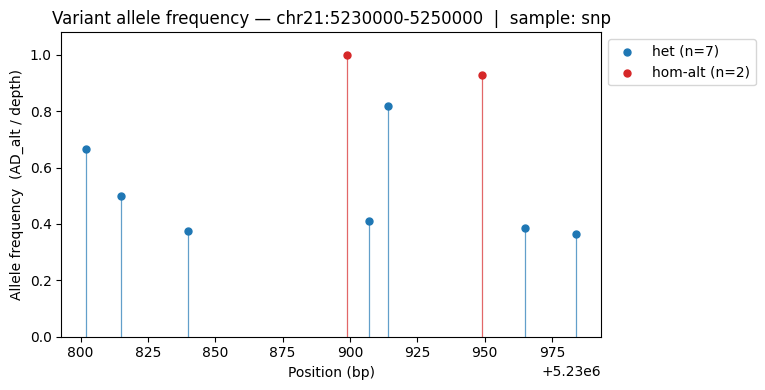

In [31]:
# plot allele frequency (AD_alt / depth) across the region
GT_STYLE = {1: ("#1f77b4", "het"), 2: ("#d62728", "hom-alt")}

pos_c = region_gt.coords["position"].values
gt_c = region_gt.sel(sample=sample).values
af_c = region_ad_a.sel(sample=sample).values / (
    region_ad_r.sel(sample=sample).values + region_ad_a.sel(sample=sample).values
)
fig, ax = plt.subplots(figsize=(8, 4))

for g, (color, label) in GT_STYLE.items():
    m = gt_c == g
    ax.vlines(pos_c[m], 0, af_c[m], color=color, linewidth=0.9, alpha=0.7)
    ax.scatter(pos_c[m], af_c[m], color=color, s=25, zorder=3, label=f"{label} (n={m.sum()})")

ax.set_xlabel("Position (bp)")
ax.set_ylabel("Allele frequency  (AD_alt / depth)")
ax.set_title(f"Variant allele frequency — {REGION}  |  sample: {sample}")
ax.set_ylim(0, 1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
fig.tight_layout()
fig.savefig(FIG_DIR / "variant_allele_frequency_region.png")
plt.show()

### 9c. Variant allele frequency across chr21

Each variant site is drawn as a lollipop at its 1-based genomic coordinate.
Height = allele frequency (`AD_alt / (AD_ref + AD_alt)`).
Colour indicates genotype: **blue** = heterozygous, **red** = homozygous-alt.

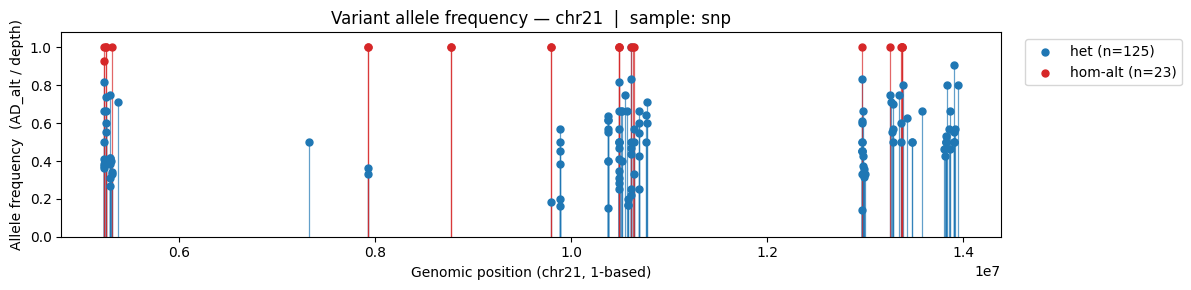

In [32]:
# Compute allele frequency for all chr21 variants
gt_all = var.to_xarray(variable="genotype")["chr21"].compute()
adr_all = var.to_xarray(variable="allele_depth_ref")["chr21"].compute()
ada_all = var.to_xarray(variable="allele_depth_alt")["chr21"].compute()

sample = var.sample_names[0]
pos_all = gt_all.coords["position"].values
gt_vals = gt_all.sel(sample=sample).values
adr_vals = adr_all.sel(sample=sample).values.astype(float)
ada_vals = ada_all.sel(sample=sample).values.astype(float)

total_depth = adr_vals + ada_vals
with np.errstate(invalid="ignore", divide="ignore"):
    af = np.where(total_depth > 0, ada_vals / total_depth, np.nan)

# Keep only called variants (het or hom-alt)
called = gt_vals >= 1
pos_c = pos_all[called]
af_c = af[called]
gt_c = gt_vals[called]

GT_STYLE = {1: ("#1f77b4", "het"), 2: ("#d62728", "hom-alt")}

fig, ax = plt.subplots(figsize=(12, 3))
for g, (color, label) in GT_STYLE.items():
    m = gt_c == g
    ax.vlines(pos_c[m], 0, af_c[m], color=color, linewidth=0.9, alpha=0.7)
    ax.scatter(pos_c[m], af_c[m], color=color, s=25, zorder=3, label=f"{label} (n={m.sum()})")

ax.set_xlabel("Genomic position (chr21, 1-based)")
ax.set_ylabel("Allele frequency  (AD_alt / depth)")
ax.set_title(f"Variant allele frequency — chr21  |  sample: {sample}")
ax.set_ylim(0, 1.08)
ax.legend(framealpha=0.8, loc="upper right", bbox_to_anchor=(1.2, 1))
fig.tight_layout()
fig.savefig(FIG_DIR / "variant_allele_frequency_chr21.png")
plt.show()